## Law Gender Bias - 3 OBJECTIVES

### Multi Task Learning

* **Dataset:** Law Gender Bias
* **Task :** Classification

* **Target 1:** Predicting bias in statements related to the Victim
* **Target 2:** Predicting bias in statements related to the Defendant
* **Target 3:** Predicting bias in statements related to the Mother

In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import json

import torch
from torch.utils.data import DataLoader, Dataset
from transformers import AutoTokenizer
from typing import Any
from collections.abc import Callable
from sklearn.model_selection import train_test_split

/home/lineccsa/mestrado/machinemoo/venv_moo/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from machinemoo import moo
from machinemoo import get_objectives, get_models
from machinemoo.analysis.visualization import plot_pareto, plot_multiple_hypervolumes
from machinemoo.analysis.metrics import compute_hypervolume_progress

from scalarization import NLPScalarization

Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10


In [ ]:
# Setting a seed for reproducibility
from machinemoo.utils.seed_config import set_np_torch_seed
set_np_torch_seed(42)

In [ ]:
PREFIX_SAVE_IMAGE = 'images/3_objs'

## Dataset and Model

In [5]:
def prepare_datasets(json_path: str): 

    with open(json_path, 'r') as f:
        data = json.load(f)

    train_keys, test_keys = train_test_split(list(data.keys()), test_size=0.1, random_state=42)
    train_keys, val_keys = train_test_split(train_keys, test_size=0.2, random_state=42)

    train_data = {key: data[key] for key in train_keys}
    val_data= {key: data[key] for key in val_keys}
    test_data = {key: data[key] for key in test_keys}
    
    return train_data, val_data, test_data 

In [6]:
#train_data, val_data, test_data = prepare_datasets('../ap/files/annotate_filled.json')
train_data, val_data, test_data = prepare_datasets('../lesao/files/annotate_filled.json')   

In [ ]:
# Use GPU if its available
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda:0


### Dataset Analysis

In [ ]:
# Dataset class
MODEL_NAME = "neuralmind/bert-base-portuguese-cased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, cache_dir="transformers")

class MultiTaskDataset(Dataset):
    """
    Flexible dataset for multi-task classification from a JSON-like dict format.
    Supports multiple text chunks and multiple label fields.
    """

    def __init__(self,
                 data: dict,
                 tokenizer,
                 max_length: int = 512,
                 chunk_field: str = "vies_contexto ",
                 label_extractors = {}
                 ) -> None:
        """
        Parameters:
        - data: loaded JSON-like dict
        - tokenizer: HuggingFace tokenizer
        - max_length: max token length
        - chunk_field: which text chunk to use (e.g., 'vies_contexto')
        - label_extractors: dictionary mapping task names to label extraction functions
        - data_type: optional, used for augmentation
        """
        self.tokenizer = tokenizer
        self.max_length = max_length

        self.texts = []
        self.labels = {task: [] for task in label_extractors}

        for item in data.values():
            for text in item.get(chunk_field, []):
                self.texts.append(text)
                for task_name, extractor_fn in label_extractors.items():
                    label = extractor_fn(item)
                    self.labels[task_name].append(label)

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        encoding = self.tokenizer.encode_plus(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            add_special_tokens=True
        )

        item = {
            'input_ids': torch.LongTensor(encoding['input_ids']),
            'attention_mask': torch.LongTensor(encoding['attention_mask'])
        }

        for task_name in self.labels:
            item[f'{task_name}'] = torch.tensor(self.labels[task_name][idx], dtype=torch.long)

        return item

In [9]:
def key_presence_extractor(key: str, subkey: str = "") -> Callable[[dict[str, Any]], int]:
    """
    Returns a function that checks if `key` (and optionally `subkey`) is present in the sample.
    Useful for binary presence labels.
    """
    def extractor(sample: dict[str, Any]) -> int:
        if subkey != "":
            result = subkey in sample.get(key, {})
        else:
            val = sample.get(key, [""])[0] if isinstance(sample.get(key), list) else sample.get(key)
            result = bool(val)
        return int(result)
    return extractor

In [ ]:
task_config = {
    #"Bias ": key_presence_extractor("vies"),
    
    #"Bias Women": key_presence_extractor("vies_alvo", subkey="abs_mul"),
    #"Mae": key_presence_extractor("vies_alvo", subkey="mae"),
    "Vitima": key_presence_extractor("vies_alvo", subkey="vitima"),
    "Reu": key_presence_extractor("vies_alvo", subkey="reu"),
    "Test": key_presence_extractor("vies_alvo", subkey="test")

}

In [ ]:
trainset = MultiTaskDataset(data=train_data, tokenizer=tokenizer, label_extractors=task_config)
train_dataloader = DataLoader(trainset, batch_size=8, shuffle=True)

valset = MultiTaskDataset(data=val_data, tokenizer=tokenizer, label_extractors=task_config)
valid_dataloader = DataLoader(valset, batch_size=8)

testset = MultiTaskDataset(data=test_data, tokenizer=tokenizer, label_extractors=task_config)
test_dataloader = DataLoader(testset, batch_size=8)


## MOO Modeling and Training

* MOO methods:
    * MOLA
    * Random Weights

In [ ]:
# Setting optimization parameter to use in all methods in this experiment
opt_params = {
    'node_time_limit': 2,
    'target_size': 500,
    'target_gap': 0,
    'node_gap': 0.05,
    'norm': False
}
results = {}
objectives_names = list(task_config.keys())

# Control optimization output (Default is False):
#   verbose=True -> show optimization progress
#   debug=True   -> show detailed debug information
verbose = False
debug = False

def machine_optimize(method, lb_estimate=0.01):
    w_scalar = NLPScalarization(
        train_dataloader = train_dataloader, 
        device = device, 
        task_names = objectives_names,
        model_name = MODEL_NAME, 
        lower_bound_estimate=lb_estimate
    )
    moopt = moo(w_scalar, verbose=verbose, debug=debug).mo_optimization(method, **opt_params)
    objs = get_objectives(moopt)
    if method == 'mola':
        hypervolume_values = moopt.get_hypervolumes()
    else:
        hypervolume_values = compute_hypervolume_progress(objs)
    if lb_estimate == 'lipschitz':
        method = f'{method}_grad'
    results[method] = {
                    "moopt": moopt,
                    "objectives": objs,
                    "models": get_models(moopt),
                    "hypervolume": hypervolume_values
                }
    
def plot_frontier(method, color="#d73027"):
    title="Loss Trade-offs in Multi-Group Hate Speech Detection"
    plot_pareto(methods={method: results[method]['objectives']},
                labels=objectives_names, 
                title=title,
                color=color,
                fontsize=20,
                figsize=(10,7),
                save_path=f'{PREFIX_SAVE_IMAGE}_{method}.pdf'
                )

### MOLA

18:35:06 | DEBUG | machinemoo | Filtered parameters for Mola: {'node_time_limit': 2, 'target_size': 500, 'target_gap': 0, 'node_gap': 0.05, 'norm': False}
18:35:06 | DEBUG | machinemoo | Finding 1th individual minimum
Evaluating: 100%|██████████| 5/5 [00:01<00:00,  4.28it/s]
18:35:10 | DEBUG | machinemoo | Finding 2th individual minimum
Evaluating: 100%|██████████| 5/5 [00:01<00:00,  4.22it/s]
18:35:14 | DEBUG | machinemoo | Finding 3th individual minimum
Evaluating: 100%|██████████| 5/5 [00:01<00:00,  4.18it/s]
18:35:18 | DEBUG | machinemoo | Calculated weights: [7.44738034e-04 9.99247039e-01 8.22291365e-06]
18:35:18 | DEBUG | machinemoo | Importance: 0.0075382611001529164
18:35:18 | DEBUG | machinemoo | Importance: 0.0075382611001529876
18:35:18 | DEBUG | machinemoo | y_sup: [  0.98395567   0.75012712 430.36839172]
18:35:18 | DEBUG | machinemoo | y_und: [0.67685922 0.74634992 0.44837378]
18:35:18 | DEBUG | machinemoo | Global lower bound (y*): [0.67685921 0.74634991 0.42637317]
Optim

@@@@@@@@@@


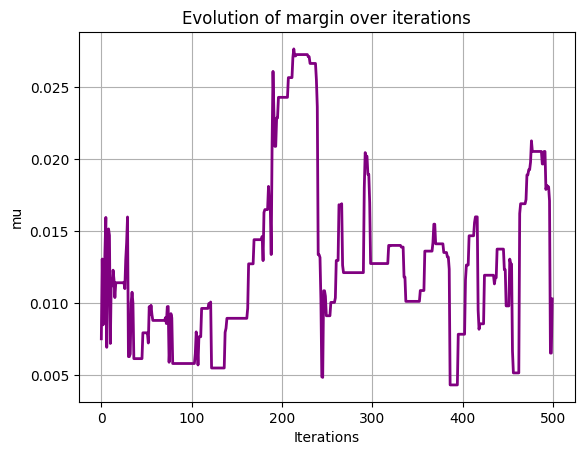

19:09:57 | INFO | machinemoo | Fit runtime: 2091.16 seconds


In [ ]:
method = 'mola'
machine_optimize(method=method)

In [ ]:
plot_frontier(method, color='#d73027')

array([[0.4009733 , 0.33497155, 0.15147393],
       [0.3609522 , 0.34332949, 0.12062855],
       [0.39941601, 0.34245992, 0.14821371],
       [0.38942932, 0.34305187, 0.15431975]])

### MOLA with gradient

19:10:13 | DEBUG | machinemoo | Filtered parameters for Mola: {'node_time_limit': 2, 'target_size': 500, 'target_gap': 0, 'node_gap': 0.05, 'norm': False}
19:10:13 | DEBUG | machinemoo | Finding 1th individual minimum


Lipschitz constants for each group: [0.55077422 0.53772467 0.51610518]


Evaluating: 100%|██████████| 5/5 [00:01<00:00,  4.19it/s]
19:10:18 | DEBUG | machinemoo | Finding 2th individual minimum
Evaluating: 100%|██████████| 5/5 [00:01<00:00,  4.11it/s]
19:10:22 | DEBUG | machinemoo | Finding 3th individual minimum
Evaluating: 100%|██████████| 5/5 [00:01<00:00,  4.13it/s]
19:10:27 | DEBUG | machinemoo | Calculated weights: [2.23509685e-01 7.76490313e-01 2.19720425e-09]
19:10:27 | DEBUG | machinemoo | Importance: 0.6827926425201893
19:10:27 | DEBUG | machinemoo | Importance: 0.6827926425201893
19:10:27 | DEBUG | machinemoo | y_sup: [1.56649455e+00 5.44170776e-01 6.63273514e+03]
19:10:27 | DEBUG | machinemoo | y_und: [0.03917498 0.10449066 0.70191149]
19:10:27 | DEBUG | machinemoo | Global lower bound (y*): [0.03917497 0.10449065 0.24678413]
Optimization Progress:   0%|          | 0/500 [00:00<?, ?it/s]19:10:27 | DEBUG | machinemoo | Iteration 1
19:10:27 | DEBUG | machinemoo | Solutions list: [array([0.72597518, 0.8263364 , 0.99333813]), array([0.71312536, 0.80

@@@@@@@@@@


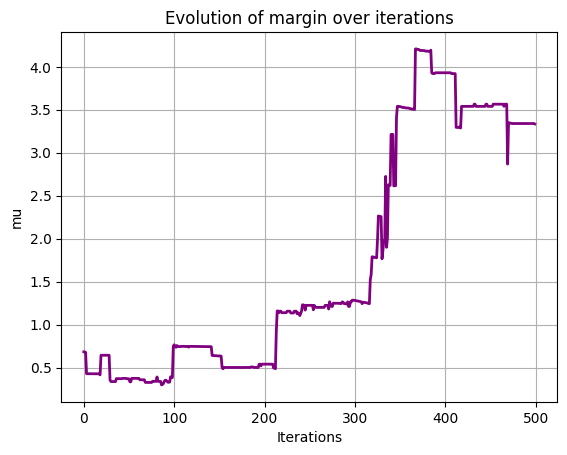

19:51:21 | INFO | machinemoo | Fit runtime: 2468.30 seconds


In [ ]:
method = 'mola'
machine_optimize(method=method, lb_estimate='lipschitz')

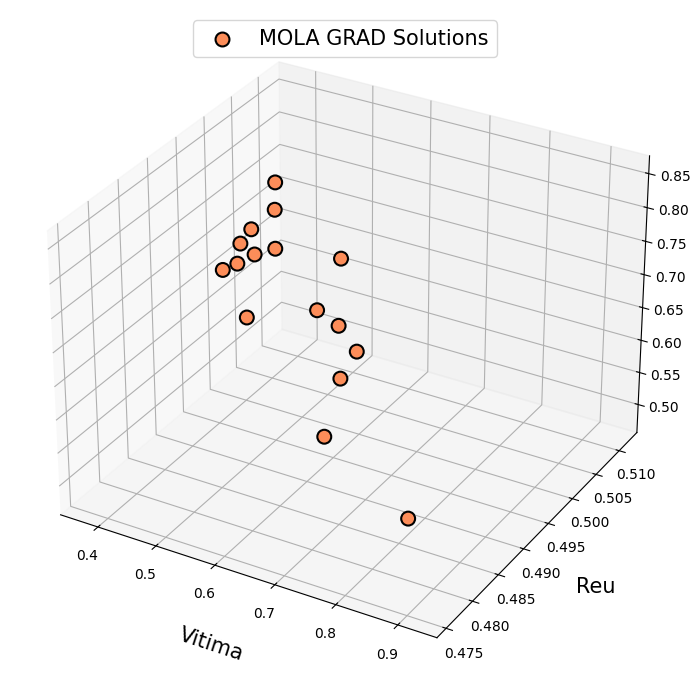

In [ ]:
plot_frontier(f'{method}_grad', color='#fc8d59')

### Random Weights

In [ ]:
method = 'random_weights'
machine_optimize(method=method)

19:51:23 | WARNING | machinemoo | Ignored parameters for random_weights: {'nodeTimeLimit', 'targetGap', 'nodeGap'}
19:51:23 | DEBUG | machinemoo | Filtered parameters for random_weights: {'targetSize': 500, 'norm': False}
19:51:23 | DEBUG | machinemoo | Finding 1th individual minima
Evaluating: 100%|██████████| 5/5 [00:01<00:00,  4.30it/s]
19:51:27 | DEBUG | machinemoo | Finding 2th individual minima
Evaluating: 100%|██████████| 5/5 [00:01<00:00,  4.04it/s]
19:51:31 | DEBUG | machinemoo | Finding 3th individual minima
Evaluating: 100%|██████████| 5/5 [00:01<00:00,  3.54it/s]
19:51:39 | DEBUG | machinemoo | 4th solution
Evaluating: 100%|██████████| 5/5 [00:01<00:00,  4.05it/s]
19:51:43 | DEBUG | machinemoo | 5th solution
Evaluating: 100%|██████████| 5/5 [00:01<00:00,  4.03it/s]
19:51:47 | DEBUG | machinemoo | 6th solution
Evaluating: 100%|██████████| 5/5 [00:01<00:00,  4.18it/s]
19:51:51 | DEBUG | machinemoo | 7th solution
Evaluating: 100%|██████████| 5/5 [00:01<00:00,  4.07it/s]
19:51:

### Non-dominated Solutions Analysis

In [ ]:
from pymoo.util.nds.non_dominated_sorting import NonDominatedSorting
rw_solutions = results['random_weights']['objectives']
nd_indices = NonDominatedSorting().do(rw_solutions, only_non_dominated_front=True)
rw_non_dominated_solutions = rw_solutions[nd_indices]

print(f'Number of non-dominated solutions with MOLA          : {len(results['mola']['objectives'])}')
print(f'Number of non-dominated solutions with MOLA GRAD     : {len(results['mola_grad']['objectives'])}')
print(f'Number of non-dominated solutions with RANDOM WEIGHT : {len(rw_non_dominated_solutions)}')

## A posteriori Decision Making

* Comparison between MOO methods
* Ensemble and Evaluation

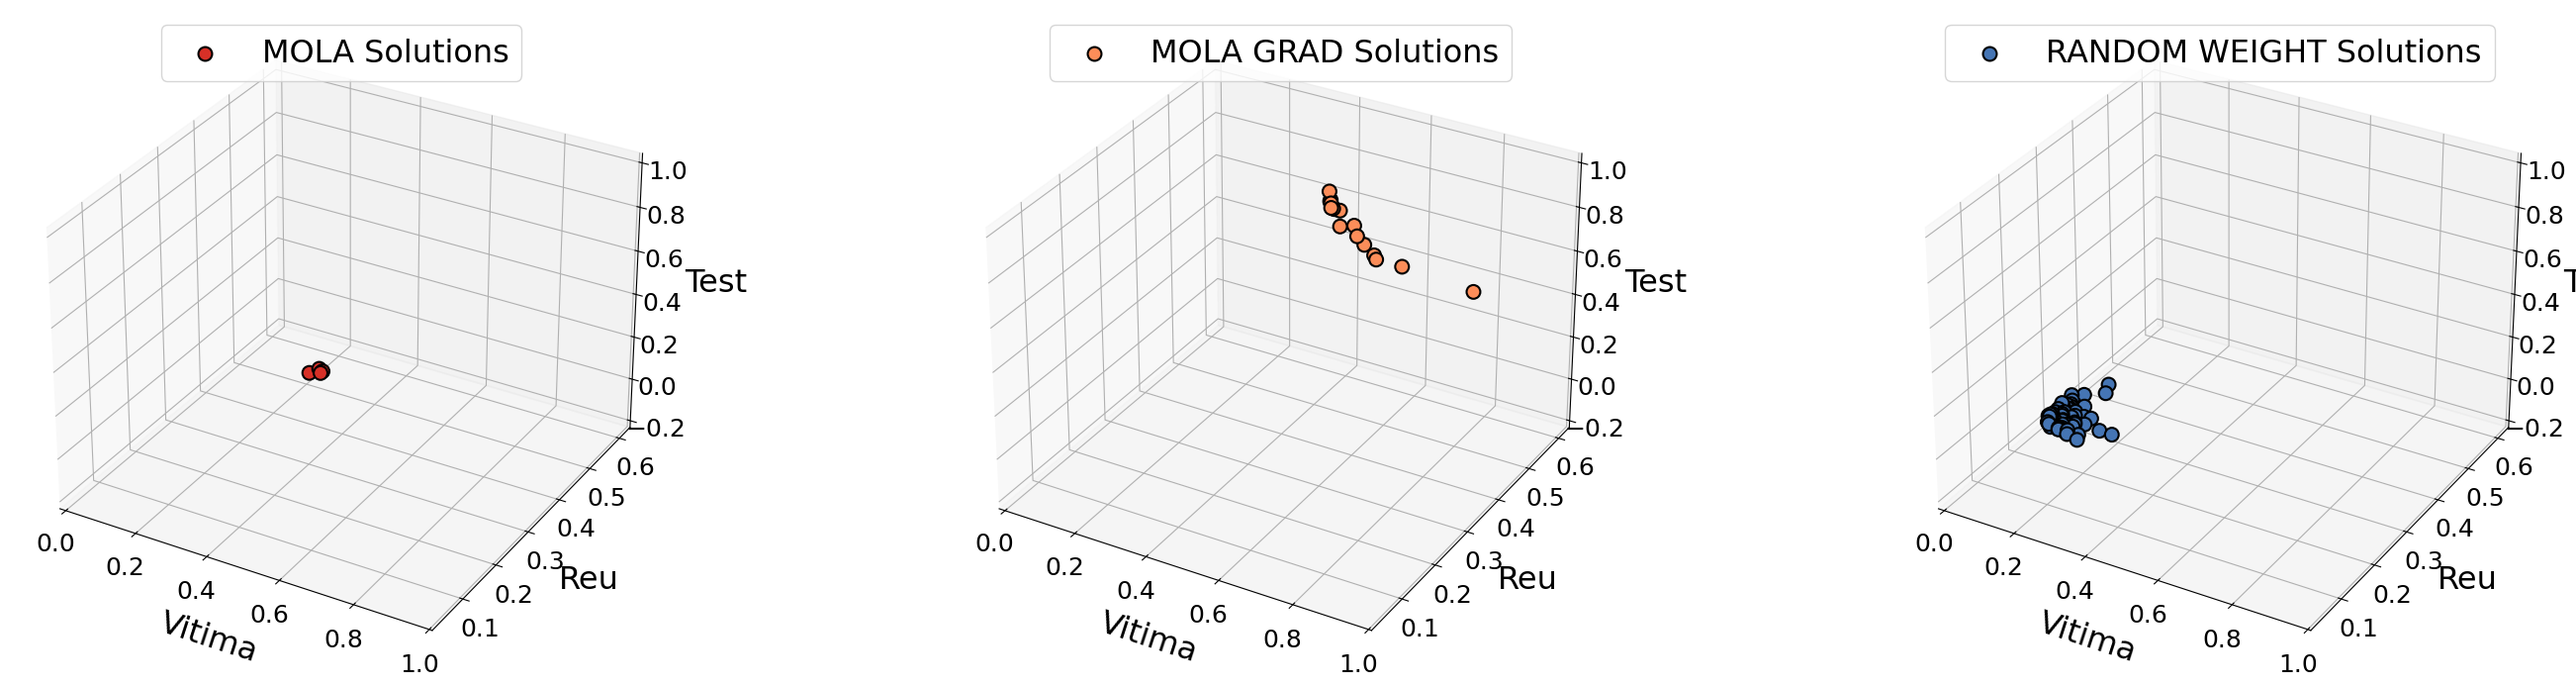

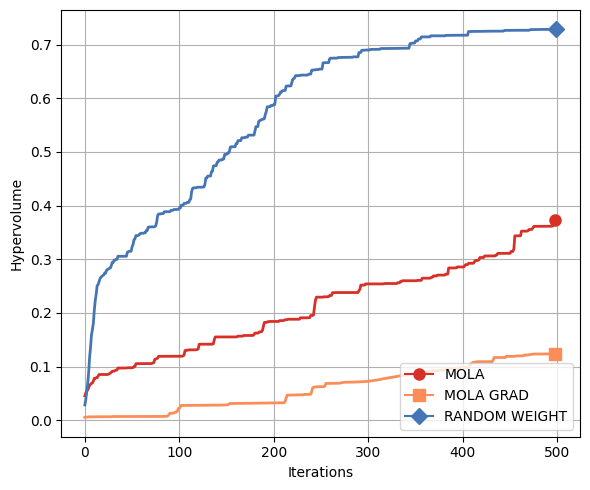

<Figure size 640x480 with 0 Axes>

In [ ]:
pareto_dict = {
        method: res['objectives']
        for method, res in results.items()
        if 'objectives' in res
    }

pareto_dict['random_weights'] = rw_non_dominated_solutions

hypervolumes_dict = {
        method: res['hypervolume']
        for method, res in results.items()
        if 'hypervolume' in res
    }

plot_pareto(methods=pareto_dict,
            labels=objectives_names, 
            #title='Comparative Pareto Frontiers Across MOO Methods',
            #subset=equal.objs,
            fontsize=23,
            figsize=(10,7),
            save_path=f'{PREFIX_SAVE_IMAGE}_methods.pdf'
            )

plot_multiple_hypervolumes(methods_hv=hypervolumes_dict, save_path=f'{PREFIX_SAVE_IMAGE}_hypervolume.pdf')

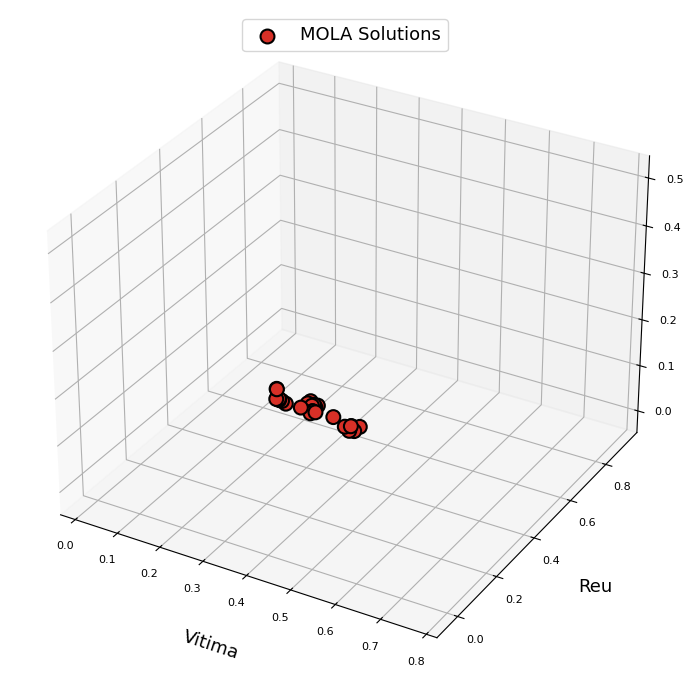

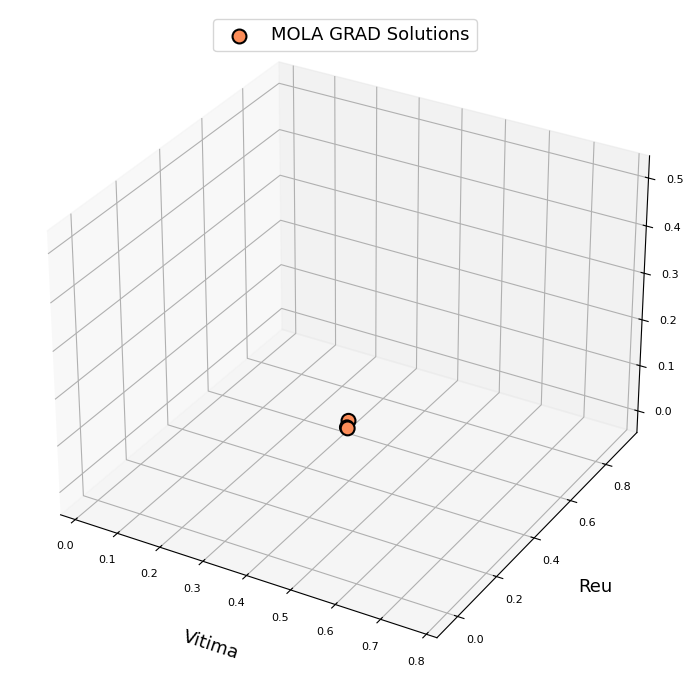

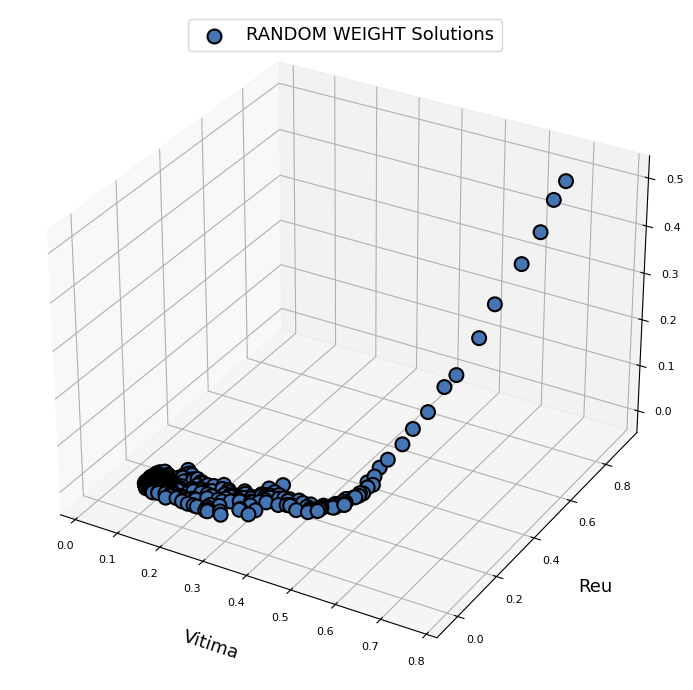

In [ ]:
import numpy as np
all_data = np.concatenate(list(pareto_dict.values()), axis=0)
limits = []
color: list[str] | str = ['#d73027', '#fc8d59', '#4575b4']

#for i in range(all_data.shape[1]):
#    limits.append(
#        (
#            all_data[:, i].min() - all_data[:, i].std(),
#            all_data[:, i].max() + all_data[:, i].std(),
#        )
#    )
first_objs = next(iter(pareto_dict.values()))
x_min, x_max = first_objs[:, 0].min() - first_objs[:, 0].std(), first_objs[:, 0].max() + first_objs[:, 0].std()
y_min, y_max = first_objs[:, 1].min() - first_objs[:, 1].std(), first_objs[:, 1].max() + first_objs[:, 1].std()

limits.append((x_min, x_max))
limits.append((y_min, y_max))

for i, (method, objs) in enumerate(pareto_dict.items()):
    plot_pareto(methods={method: objs},
                color = color[i],
                labels=objectives_names, 
                #title=title,
                fontsize=13,
                figsize=(10,7),
                save_path=f'{PREFIX_SAVE_IMAGE}_{method}_limit.pdf',
                limits=limits
    )